In [23]:
import pandas as pd

In [24]:
df=pd.read_csv("House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [26]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le=LabelEncoder()
df["Location"]=le.fit_transform(df["Location"])

In [29]:
df["Condition"]=le.fit_transform(df["Condition"])

In [30]:
df["Garage"]=le.fit_transform(df["Garage"])

In [31]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,2,3,0,295620
1996,1997,3046,5,2,1,2019,2,3,1,580929
1997,1998,1062,5,1,2,1903,1,3,0,476925
1998,1999,4062,3,1,2,1936,3,0,1,161119


In [32]:
df=df.drop("Id",axis=1)
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,0,0,0,149919
1,4272,5,4,3,1958,0,0,0,424998
2,3592,2,2,3,1938,0,2,0,266746
3,966,4,2,2,1902,2,1,1,244020
4,4926,1,4,2,1975,0,1,1,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,3,0,295620
1996,3046,5,2,1,2019,2,3,1,580929
1997,1062,5,1,2,1903,1,3,0,476925
1998,4062,3,1,2,1936,3,0,1,161119


In [35]:
X=df.drop("Price",axis=1)
y=df["Price"]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression

In [50]:
#univariant
lr=LinearRegression()
X_lr=X_train[["Area"]]
lr.fit(X_lr,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
y_pred=lr.predict(X_test[["Area"]])

In [54]:
print("Coefficient:", lr.coef_[0])
print("Intercept:", lr.intercept_)

Coefficient: -0.18386104195285485
Intercept: 536693.6793940249


In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [58]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE : 242478.32249473498
MSE : 77856127383.1798
RMSE: 279027.1086887075
R2 Score: -0.0007365003351658128


In [60]:
import matplotlib.pyplot as plt

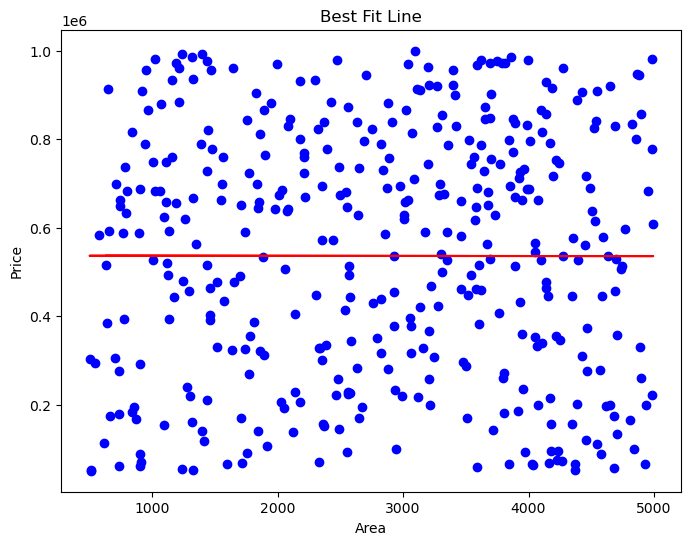

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(X_test[["Area"]], y_test, color='blue')
plt.plot(X_test[["Area"]], y_pred, color='red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Best Fit Line")

plt.show()

In [67]:
import statsmodels.api as sm
X = sm.add_constant(X)

ols_model = sm.OLS(y,X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9723
Date:                Thu, 16 Jul 2026   Prob (F-statistic):              0.456
Time:                        22:44:42   Log-Likelihood:                -27893.
No. Observations:                2000   AIC:                         5.580e+04
Df Residuals:                    1991   BIC:                         5.585e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.434e+05    3.4e+05      1.304      0.1

In [75]:

model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [81]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [-3.84679917e-01  1.32914377e+02 -9.93804686e+03  2.36609202e+04
  1.12689462e+02 -2.58109948e+03 -2.57769020e+03  3.85995776e+03]
Intercept: 299483.8142546379


In [76]:
from sklearn.linear_model import Ridge,Lasso

In [77]:

ridge = Ridge(alpha=1.0)

ridge.fit(X_train,y_train)

y_pred = ridge.predict(X_test)

print("Ridge Coefficients")
print(ridge.coef_)

print("R2 Score:", r2_score(y_test,y_pred))

Ridge Coefficients
[-3.84454093e-01  1.32609891e+02 -9.93273523e+03  2.36378853e+04
  1.12684312e+02 -2.57963746e+03 -2.57612230e+03  3.84893845e+03]
R2 Score: -0.011948842379038593


In [78]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

y_pred = lasso.predict(X_test)

print("LASSO Coefficients")
print(lasso.coef_)

print("R2 Score:", r2_score(y_test,y_pred))

LASSO Coefficients
[-3.84676928e-01  1.32854937e+02 -9.93796276e+03  2.36607546e+04
  1.12689284e+02 -2.58101815e+03 -2.57760914e+03  3.85952712e+03]
R2 Score: -0.011961396749745612


In [79]:
linear = LinearRegression()
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1)

linear.fit(X_train,y_train)
ridge.fit(X_train,y_train)
lasso.fit(X_train,y_train)

print("Linear R2 :", linear.score(X_test,y_test))
print("Ridge R2  :", ridge.score(X_test,y_test))
print("LASSO R2  :", lasso.score(X_test,y_test))

Linear R2 : -0.011961539273188437
Ridge R2  : -0.011948842379038593
LASSO R2  : -0.011961396749745612
